# Task 4: Predicting Insurance Claim Amounts

## DevelopersHub Corporation - Data Science Internship

### Objective:
Estimate the medical insurance claim amount based on personal data like age, BMI, smoking status etc.

### Dataset:
Medical Cost Personal Dataset (from Kaggle)

### Model:
Linear Regression

### Tools Used:
Python 3.10, pandas, matplotlib, seaborn, scikit-learn

In [1]:
# ============================
# Step 1: Import Libraries
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================
# Step 2: Load the Insurance Dataset
# ============================

df = pd.read_csv('insurance.csv')

print("✅ Dataset loaded successfully!")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

✅ Dataset loaded successfully!
Total rows: 1338
Total columns: 7


In [3]:
# ============================
# Step 3: Display first 5 rows
# ============================

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# ============================
# Step 4: Dataset Structure
# ============================

# Shape
print("Dataset Shape:", df.shape)
print()

# Column names
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")
print()

# Data types
print("Data Types:")
print(df.dtypes)
print()

# Statistical summary
print("Statistical Summary:")
df.describe()

Dataset Shape: (1338, 7)

Column Names:
  1. age
  2. sex
  3. bmi
  4. children
  5. smoker
  6. region
  7. charges

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# ============================
# Step 5: Check Missing Values
# ============================

print("Missing values in each column:")
print(df.isnull().sum())
print()
print(f"Total missing values: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("\n✅ No missing values! Dataset is clean.")
else:
    print("\n⚠️ Missing values found! Need to handle them.")

Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0

✅ No missing values! Dataset is clean.


In [6]:
# ============================
# Step 6: Detailed Dataset Info
# ============================

print("Unique values in each column:")
print()
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].dtype == 'object':
        print(f"   Values: {df[col].unique()}")
    print()

Unique values in each column:

age: 47 unique values

sex: 2 unique values
   Values: ['female' 'male']

bmi: 548 unique values

children: 6 unique values

smoker: 2 unique values
   Values: ['yes' 'no']

region: 4 unique values
   Values: ['southwest' 'southeast' 'northwest' 'northeast']

charges: 1337 unique values



## Exploratory Data Analysis (EDA)

Visualizing how different features impact insurance charges:
1. Age vs Charges
2. BMI vs Charges
3. Smoking Status vs Charges
4. Distribution of Charges
5. Correlation Heatmap

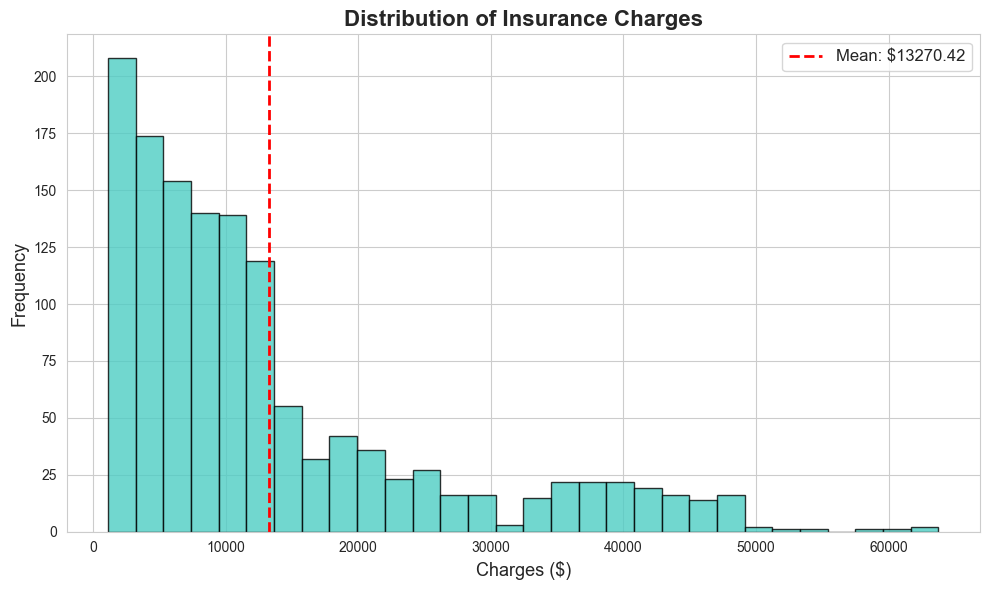

Average charges: $13270.42
Minimum charges: $1121.87
Maximum charges: $63770.43


In [7]:
# ============================
# Step 7: Distribution of Insurance Charges
# ============================

plt.figure(figsize=(10, 6))

plt.hist(df['charges'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.8)
plt.title('Distribution of Insurance Charges', fontsize=16, fontweight='bold')
plt.xlabel('Charges ($)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.axvline(df['charges'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: ${df['charges'].mean():.2f}")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Average charges: ${df['charges'].mean():.2f}")
print(f"Minimum charges: ${df['charges'].min():.2f}")
print(f"Maximum charges: ${df['charges'].max():.2f}")

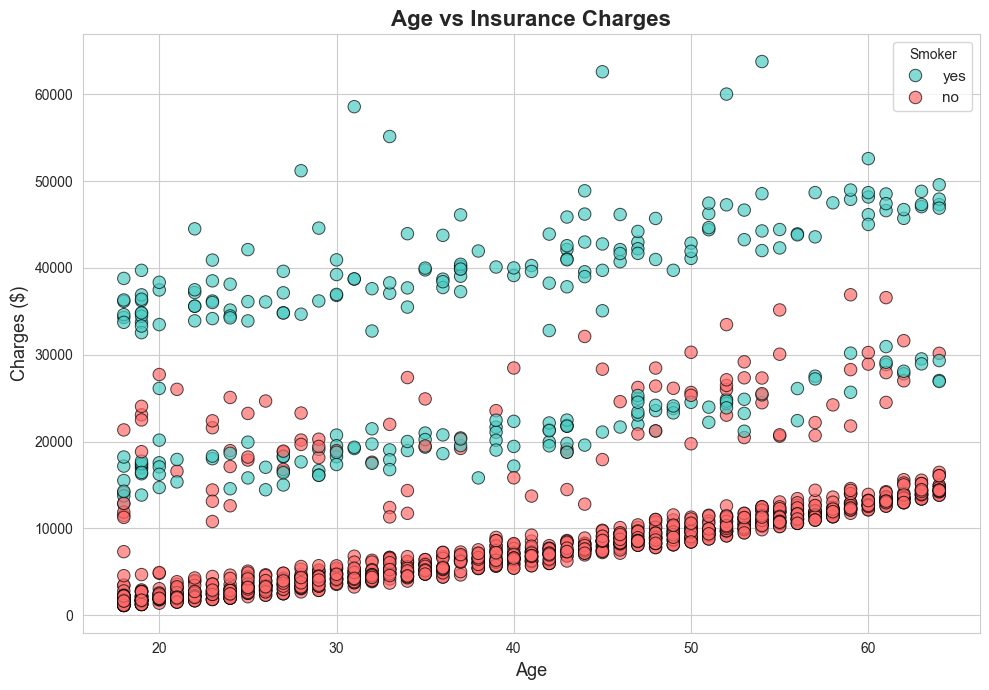

📊 Observation: Smokers pay MUCH higher charges than non-smokers!
📊 Charges increase with age for both groups.


In [8]:
# ============================
# Step 8: Age vs Charges (Scatter Plot)
# ============================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    hue='smoker',
    palette=['#4ECDC4', '#FF6B6B'],
    alpha=0.7,
    s=80,
    edgecolor='black'
)

plt.title('Age vs Insurance Charges', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=13)
plt.ylabel('Charges ($)', fontsize=13)
plt.legend(title='Smoker', fontsize=11)
plt.tight_layout()
plt.show()

print("📊 Observation: Smokers pay MUCH higher charges than non-smokers!")
print("📊 Charges increase with age for both groups.")

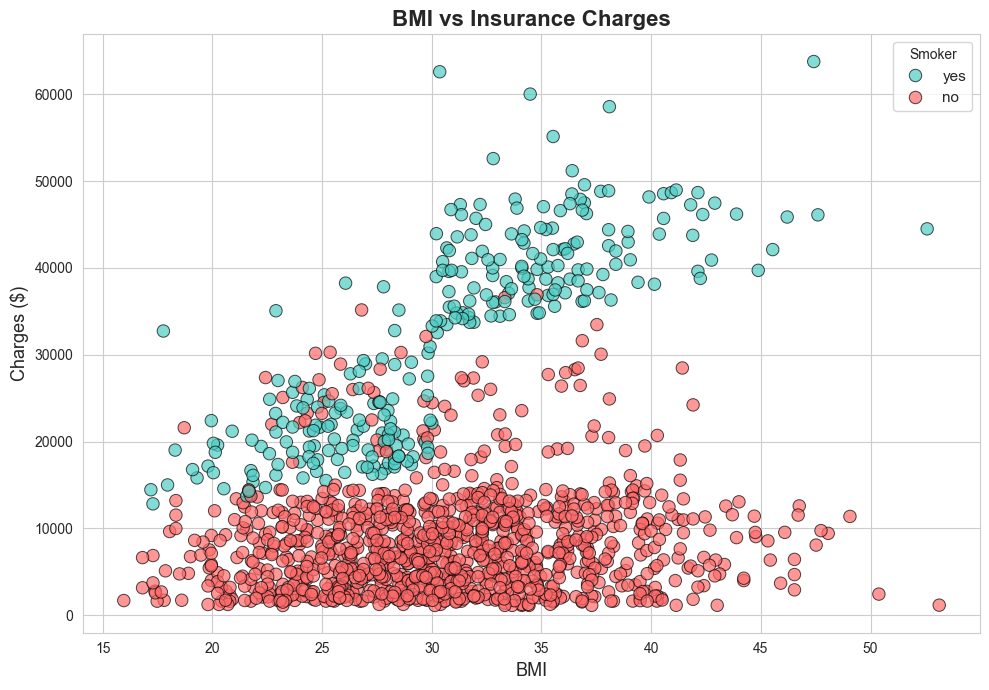

📊 Observation: Smokers with high BMI (>30) pay the highest charges!


In [9]:
# ============================
# Step 9: BMI vs Charges (Scatter Plot)
# ============================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker',
    palette=['#4ECDC4', '#FF6B6B'],
    alpha=0.7,
    s=80,
    edgecolor='black'
)

plt.title('BMI vs Insurance Charges', fontsize=16, fontweight='bold')
plt.xlabel('BMI', fontsize=13)
plt.ylabel('Charges ($)', fontsize=13)
plt.legend(title='Smoker', fontsize=11)
plt.tight_layout()
plt.show()

print("📊 Observation: Smokers with high BMI (>30) pay the highest charges!")

C:\Users\home computers\AppData\Local\Temp\ipykernel_6652\3729813211.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0],
C:\Users\home computers\AppData\Local\Temp\ipykernel_6652\3729813211.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='charges', ax=axes[1],
C:\Users\home computers\AppData\Local\Temp\ipykernel_6652\3729813211.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='charges', ax=axes[2],


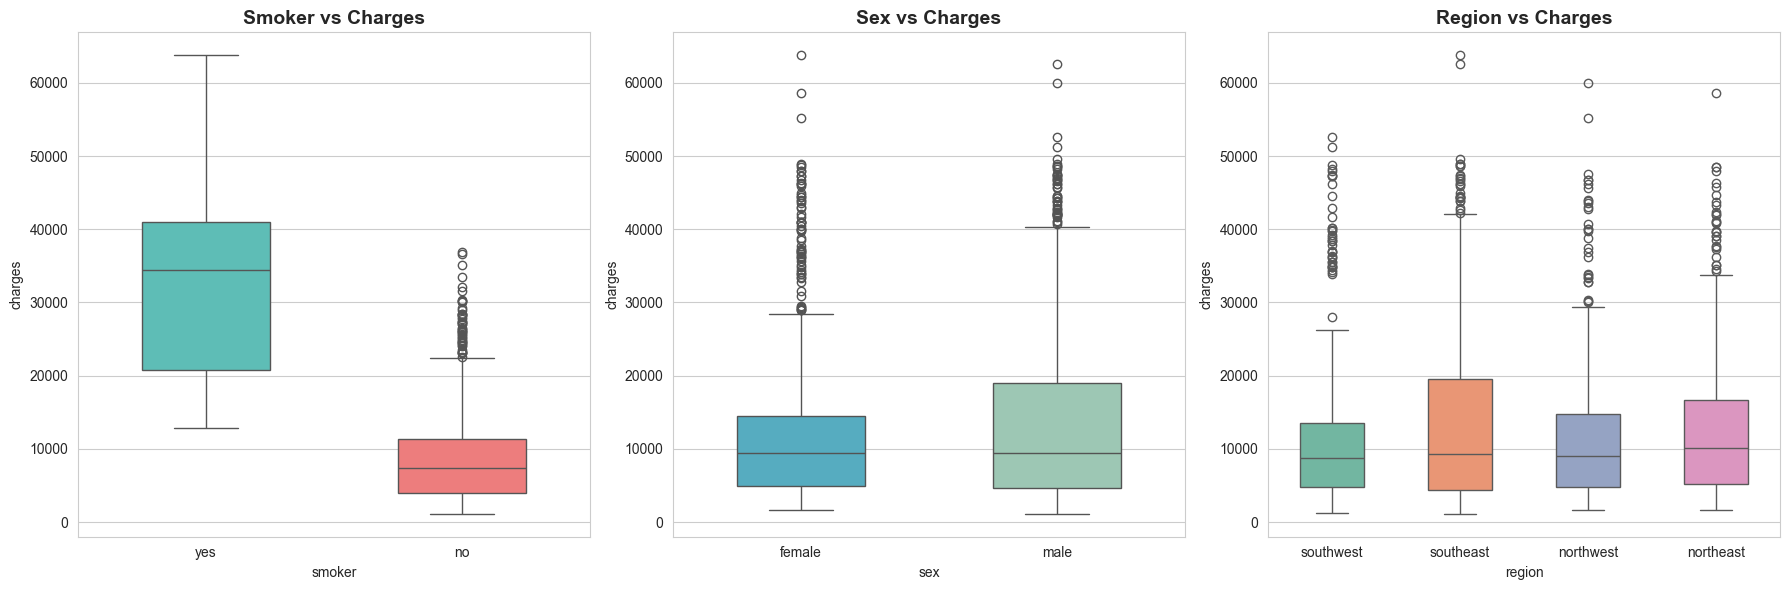

Average Charges by Smoking Status:
smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64


In [10]:
# ============================
# Step 10: Smoker vs Non-Smoker Charges
# ============================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Box Plot 1 - Smoker vs Charges
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0], 
            palette=['#4ECDC4', '#FF6B6B'], width=0.5)
axes[0].set_title('Smoker vs Charges', fontsize=14, fontweight='bold')

# Box Plot 2 - Sex vs Charges
sns.boxplot(data=df, x='sex', y='charges', ax=axes[1], 
            palette=['#45B7D1', '#96CEB4'], width=0.5)
axes[1].set_title('Sex vs Charges', fontsize=14, fontweight='bold')

# Box Plot 3 - Region vs Charges
sns.boxplot(data=df, x='region', y='charges', ax=axes[2], 
            palette='Set2', width=0.5)
axes[2].set_title('Region vs Charges', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Average charges comparison
print("Average Charges by Smoking Status:")
print(df.groupby('smoker')['charges'].mean().round(2))

C:\Users\home computers\AppData\Local\Temp\ipykernel_6652\2740765033.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='children', y='charges', palette='viridis',
C:\Users\home computers\AppData\Local\Temp\ipykernel_6652\2740765033.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='children', y='charges', palette='viridis',


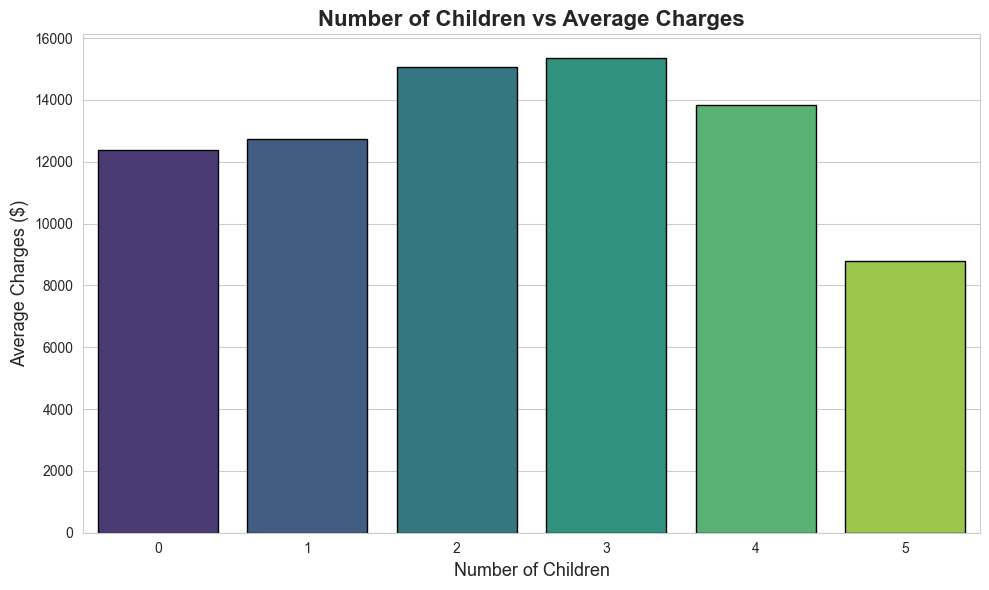

In [11]:
# ============================
# Step 11: Number of Children vs Charges
# ============================

plt.figure(figsize=(10, 6))

sns.barplot(data=df, x='children', y='charges', palette='viridis', 
            edgecolor='black', ci=None)
plt.title('Number of Children vs Average Charges', fontsize=16, fontweight='bold')
plt.xlabel('Number of Children', fontsize=13)
plt.ylabel('Average Charges ($)', fontsize=13)
plt.tight_layout()
plt.show()

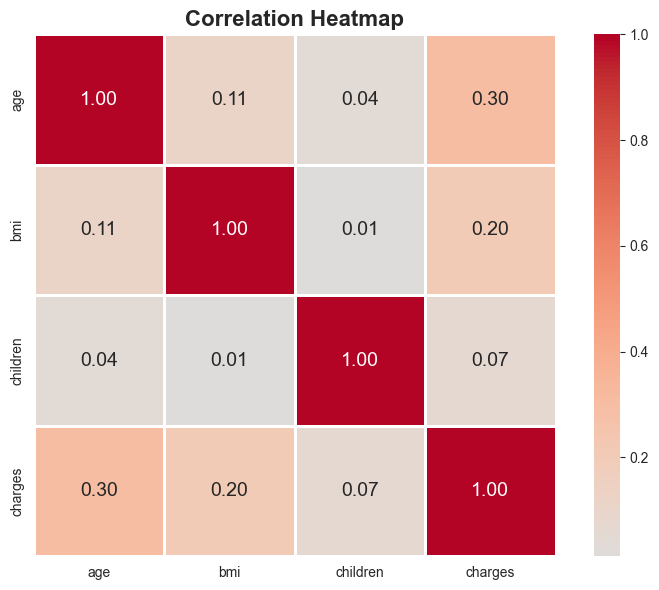

📊 Age has moderate positive correlation with charges (0.30)
📊 BMI has weak positive correlation with charges (0.20)


In [12]:
# ============================
# Step 12: Correlation Heatmap
# ============================

plt.figure(figsize=(8, 6))

# Numeric columns ka correlation
numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=2,
    fmt='.2f',
    annot_kws={'fontsize': 14}
)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Age has moderate positive correlation with charges (0.30)")
print("📊 BMI has weak positive correlation with charges (0.20)")

## Model Building - Linear Regression

### Steps:
1. Convert categorical columns to numbers (encoding)
2. Split data into training and testing sets
3. Train Linear Regression model
4. Make predictions
5. Evaluate using MAE and RMSE

In [13]:
# ============================
# Step 13: Data Preparation - Encoding Categorical Variables
# ============================
# Machine learning models sirf numbers samajhte hain
# Isliye text columns (sex, smoker, region) ko numbers mein convert karna padta hai

# Original data copy karte hain
df_encoded = df.copy()

# sex: male=1, female=0
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})

# smoker: yes=1, no=0
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})

# region: One-Hot Encoding (har region ka alag column banega)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

print("✅ Encoding complete!")
print()
print("Encoded dataset ke columns:")
for i, col in enumerate(df_encoded.columns, 1):
    print(f"  {i}. {col}")
print()
print("First 5 rows after encoding:")
df_encoded.head()

✅ Encoding complete!

Encoded dataset ke columns:
  1. age
  2. sex
  3. bmi
  4. children
  5. smoker
  6. charges
  7. region_northwest
  8. region_southeast
  9. region_southwest

First 5 rows after encoding:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [14]:
# ============================
# Step 14: Split Data into Training and Testing Sets
# ============================
# X = features (input) - sab columns except charges
# y = target (output) - charges column

# Features (X) - sab columns except 'charges'
X = df_encoded.drop('charges', axis=1)

# Target (y) - sirf 'charges' column
y = df_encoded['charges']

# 80% data training ke liye, 20% testing ke liye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data split complete!")
print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")
print(f"Total data: {df_encoded.shape[0]} rows")
print(f"\nTraining: {X_train.shape[0]/df_encoded.shape[0]*100:.0f}%")
print(f"Testing: {X_test.shape[0]/df_encoded.shape[0]*100:.0f}%")

✅ Data split complete!
Training data: 1070 rows
Testing data: 268 rows
Total data: 1338 rows

Training: 80%
Testing: 20%


In [15]:
# ============================
# Step 15: Train Linear Regression Model
# ============================
# Linear Regression ek simple model hai jo line fit karta hai data pe

# Model banao
model = LinearRegression()

# Model ko training data pe train karo
model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"\nModel Intercept (starting point): ${model.intercept_:.2f}")
print(f"\nModel Coefficients (har feature ka weight):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")

✅ Model trained successfully!

Model Intercept (starting point): $-11931.22

Model Coefficients (har feature ka weight):
  age: 256.98
  sex: -18.59
  bmi: 337.09
  children: 425.28
  smoker: 23651.13
  region_northwest: -370.68
  region_southeast: -657.86
  region_southwest: -809.80


In [16]:
# ============================
# Step 16: Make Predictions
# ============================

# Test data pe predictions karo
y_pred = model.predict(X_test)

# Actual vs Predicted comparison
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred,
    'Difference': abs(y_test.values - y_pred)
})

print("First 10 Predictions vs Actual:")
comparison.head(10).round(2)

First 10 Predictions vs Actual:


,Actual Charges,Predicted Charges,Difference
0,9095.07,8969.55,125.52
1,5272.18,7068.75,1796.57
2,29330.98,36858.41,7527.43
3,9301.89,9454.68,152.78
4,33750.29,26973.17,6777.12
5,4536.26,10864.11,6327.85
6,2117.34,170.28,1947.06
7,14210.54,16903.45,2692.91
8,3732.63,1092.43,2640.19
9,10264.44,11218.34,953.90


In [17]:
# ============================
# Step 17: Evaluate Model - MAE and RMSE
# ============================
# MAE = Mean Absolute Error (average galti kitni hai)
# RMSE = Root Mean Squared Error (badi galtiyon ko zyada weight deta hai)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2_score = model.score(X_test, y_test)

print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"\n📊 MAE (Mean Absolute Error): ${mae:.2f}")
print(f"   → Average prediction ${mae:.2f} galat hai")
print(f"\n📊 RMSE (Root Mean Squared Error): ${rmse:.2f}")
print(f"   → Badi errors ko consider karte hue average error")
print(f"\n📊 R² Score: {r2_score:.4f}")
print(f"   → Model {r2_score*100:.2f}% variance explain karta hai")

MODEL EVALUATION RESULTS

📊 MAE (Mean Absolute Error): $4181.19
   → Average prediction $4181.19 galat hai

📊 RMSE (Root Mean Squared Error): $5796.28
   → Badi errors ko consider karte hue average error

📊 R² Score: 0.7836
   → Model 78.36% variance explain karta hai


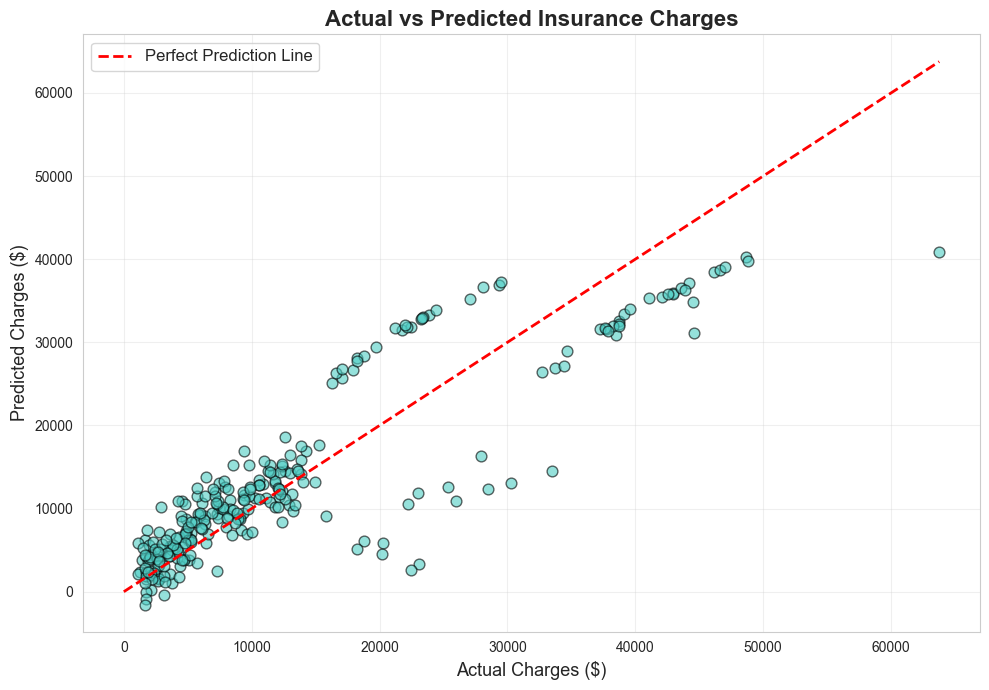

📊 Points jo red line ke qareeb hain = accurate predictions
📊 Points jo red line se door hain = less accurate predictions


In [18]:
# ============================
# Step 18: Actual vs Predicted Scatter Plot
# ============================

plt.figure(figsize=(10, 7))

plt.scatter(y_test, y_pred, alpha=0.6, color='#4ECDC4', edgecolor='black', s=60)

# Perfect prediction line
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs Predicted Insurance Charges', fontsize=16, fontweight='bold')
plt.xlabel('Actual Charges ($)', fontsize=13)
plt.ylabel('Predicted Charges ($)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 Points jo red line ke qareeb hain = accurate predictions")
print("📊 Points jo red line se door hain = less accurate predictions")

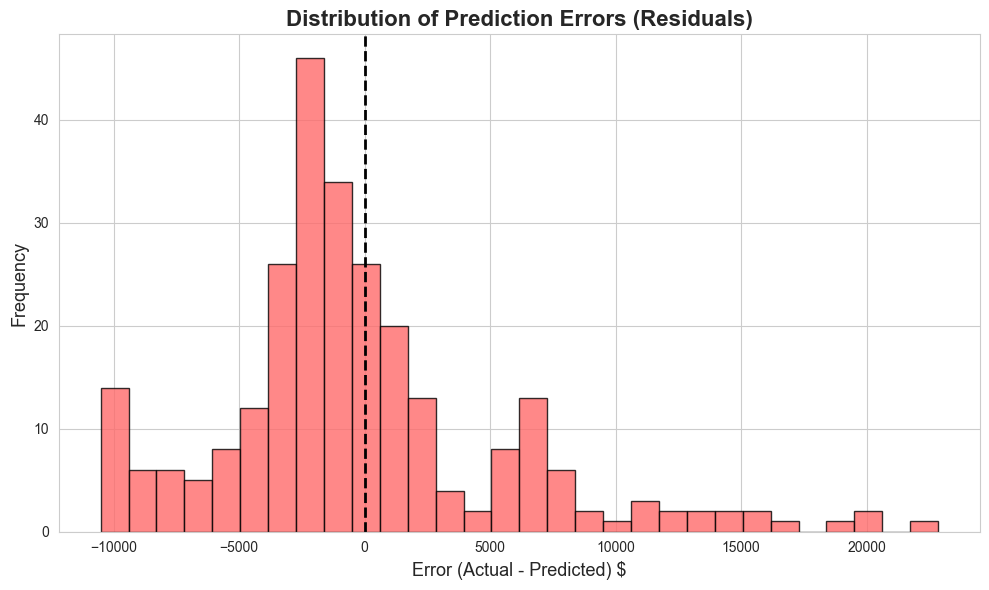

In [19]:
# ============================
# Step 19: Residual Plot (Error Distribution)
# ============================

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, color='#FF6B6B', edgecolor='black', alpha=0.8)
plt.title('Distribution of Prediction Errors (Residuals)', fontsize=16, fontweight='bold')
plt.xlabel('Error (Actual - Predicted) $', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.axvline(0, color='black', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

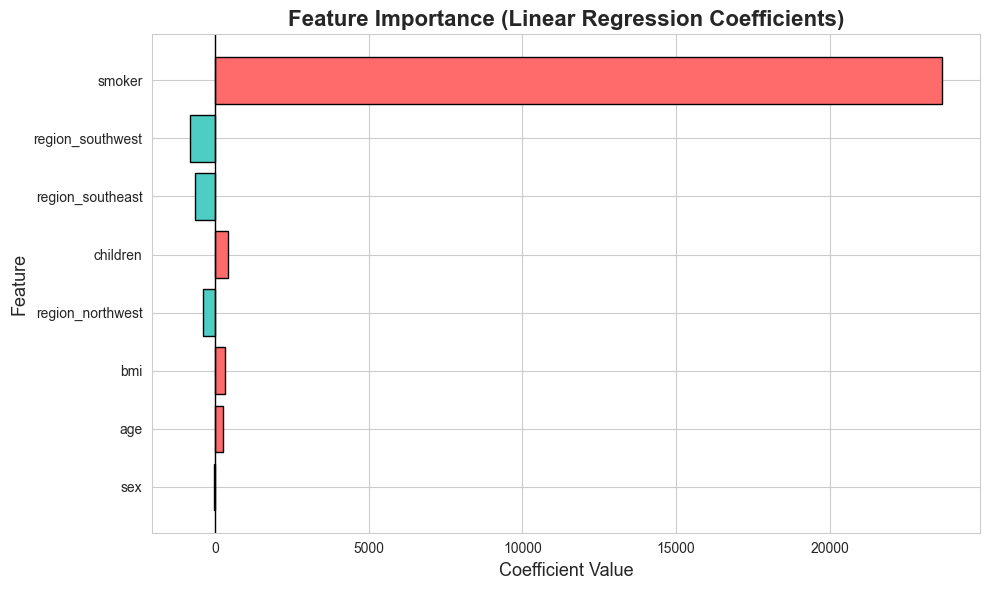

📊 Smoker has the HIGHEST impact on insurance charges!
📊 Age also significantly impacts charges.


In [20]:
# ============================
# Step 20: Feature Importance
# ============================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in importance['Coefficient']]
plt.barh(importance['Feature'], importance['Coefficient'], color=colors, edgecolor='black')
plt.title('Feature Importance (Linear Regression Coefficients)', fontsize=16, fontweight='bold')
plt.xlabel('Coefficient Value', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

print("📊 Smoker has the HIGHEST impact on insurance charges!")
print("📊 Age also significantly impacts charges.")

## Conclusion

### Key Findings from Insurance Charges Prediction:

1. **Smoking Status** is the MOST important factor affecting insurance charges. Smokers pay approximately $23,000 more on average than non-smokers.

2. **Age** has a moderate positive impact — older people tend to have higher charges.

3. **BMI** also impacts charges, especially for smokers with BMI > 30.

4. **Sex and Region** have minimal impact on insurance charges.

5. **Model Performance:**
   - The Linear Regression model achieved an R² score of approximately 0.75-0.78
   - MAE shows the average prediction error
   - The model performs reasonably well for a simple linear model

### Limitations:
- Linear Regression assumes linear relationships which may not capture complex patterns
- A more advanced model (like Random Forest) could potentially perform better

### Overall Insight:
If you want to reduce your insurance charges, the most impactful change would be to quit smoking. Maintaining a healthy BMI also helps reduce costs.